In [1]:
import utils as utils
import numpy as np
import matplotlib.pyplot as plt

[2.         2.03141076 2.06279052 ... 1.90589169 1.93720948 1.96858924]


<BarContainer object of 101 artists>

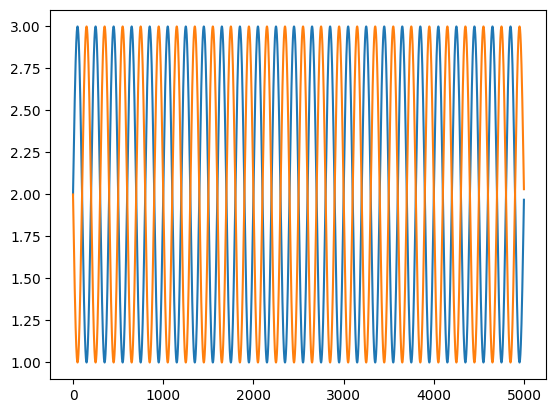

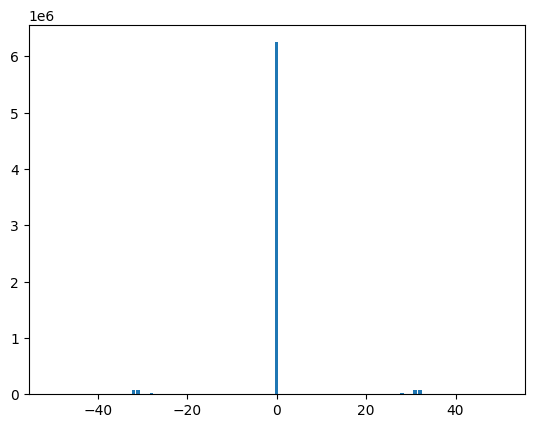

In [29]:
# a = np.arange(0, 100, 0.1)
# b = a + 1.3
# Define the parameters
frequency = 5  # Frequency of the sine wave (in Hz)
amplitude = 1  # Amplitude of the sine wave
num_points = 5000  # Total number of data points
sampling_rate = 1000  # Sampling rate (number of samples per second)

# Generate the time axis
t = np.arange(num_points) / sampling_rate

# Generate the sine wave
a = amplitude * np.sin(2 * np.pi * frequency * t) + 2
print(a)
# creat b with a shift to a 
b = np.roll(a, 100)
fig, axs = plt.subplots()
axs.plot(a)
axs.plot(b)
# print(len(a), len(b))
sparse_trains = utils.sparse_train([a, b])
counts, lags = utils.ccg(sparse_trains[0],
                        sparse_trains[1],
                        ccg_win=[-50, 50])
fig, axs = plt.subplots()
axs.bar(lags, counts)
# plt.xlim(20, 40)

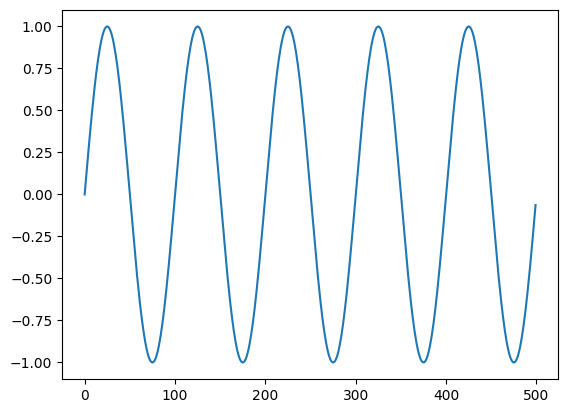

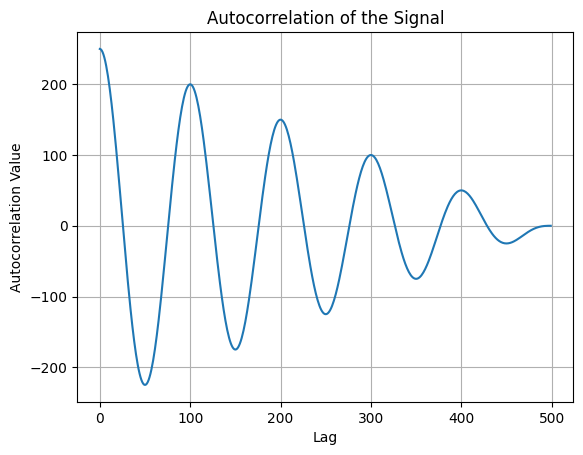

In [34]:
# Example: Create a sine wave with noise
from scipy.signal import fftconvolve
t = np.linspace(0, 1, 500, endpoint=False)
# signal = np.sin(2 * np.pi * 5 * t) + np.random.normal(0, 0.5, t.size)
signal = np.sin(2 * np.pi * 5 * t) 
fig, axs = plt.subplots()
axs.plot(signal)
# Autocorrelation using fftconvolve
result = fftconvolve(signal, signal[::-1], mode='full')
# The result needs to be normalized and centered
autocorr = result[result.size // 2:]
fig, axs = plt.subplots()
plt.plot(autocorr)
plt.title("Autocorrelation of the Signal")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation Value")
plt.grid(True)
plt.show()
